
tx_pol=V, rx_pol=V
a_real shape: (1, 1, 1, 1, 2)
Total Receiver: 1
Total Receiver Antenna (Polarization Count): 1
Total Transmitter: 1
Total Transmitter Antenna (Polarization Count): 1
Total paths found: 2

tx_pol=V, rx_pol=H
a_real shape: (1, 1, 1, 1, 2)
Total Receiver: 1
Total Receiver Antenna (Polarization Count): 1
Total Transmitter: 1
Total Transmitter Antenna (Polarization Count): 1
Total paths found: 2

tx_pol=V, rx_pol=VH
a_real shape: (1, 2, 1, 1, 2)
Total Receiver: 1
Total Receiver Antenna (Polarization Count): 2
Total Transmitter: 1
Total Transmitter Antenna (Polarization Count): 1
Total paths found: 2

tx_pol=V, rx_pol=cross
a_real shape: (1, 2, 1, 1, 2)
Total Receiver: 1
Total Receiver Antenna (Polarization Count): 2
Total Transmitter: 1
Total Transmitter Antenna (Polarization Count): 1
Total paths found: 2

tx_pol=H, rx_pol=V
a_real shape: (1, 1, 1, 1, 2)
Total Receiver: 1
Total Receiver Antenna (Polarization Count): 1
Total Transmitter: 1
Total Transmitter Antenna (Pola

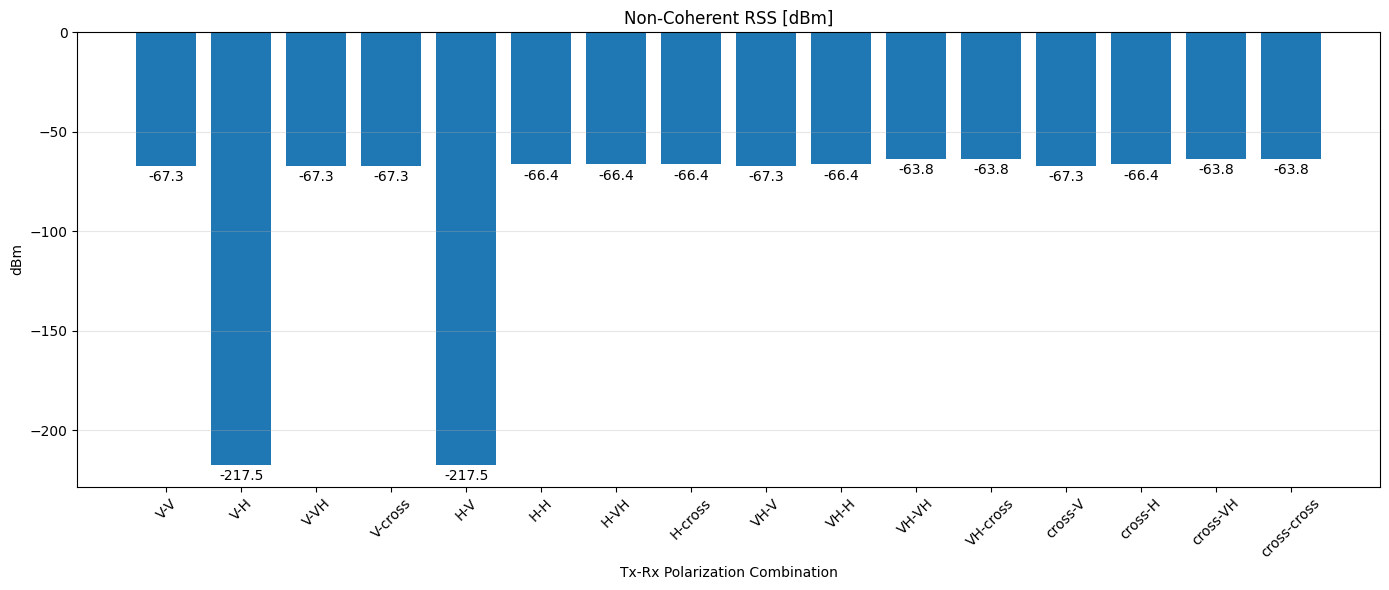

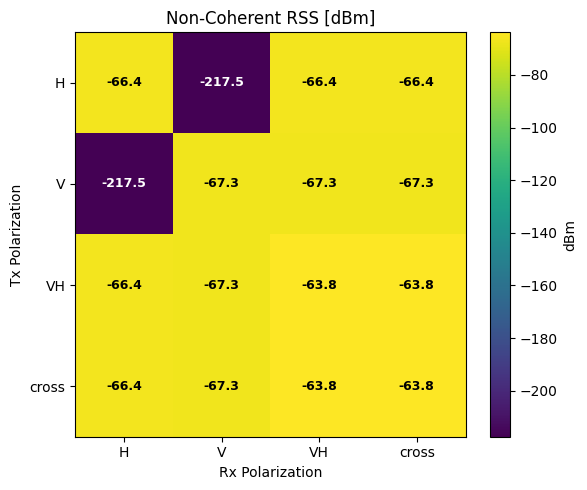

In [13]:
# Import libraries
import numpy as np
from sionna.rt import load_scene, ITURadioMaterial, Transmitter, Receiver, PlanarArray, RadioMapSolver, PathSolver, Camera
import matplotlib.pyplot as plt
import pandas as pd
import os

# Import scene from blender mitsuba export (.xml)
scene = load_scene("blender-assets/1km-field.xml")

# Add frequency to scene
carrier_freq = 1.7e9 # In Hz
scene.frequency = carrier_freq

# Deploy Tx and Rx location

# Helper function to sync transmitter 0 degree with scene 0 degree
def compass_orientation(azimuth_deg, tilt_deg=0, roll_deg=0):

    # Sionna by default implement 0 degree Tx at X+ axis, -90 to achieve 0 degree at Y+ axis (North)
    sionna_azimuth = (90 - azimuth_deg) % 360

    # return radian
    return [
        float(np.deg2rad(sionna_azimuth)),
        float(np.deg2rad(tilt_deg)),
        float(np.deg2rad(roll_deg))
    ]

# Deploy Tx
tx_azimuth_deg = 0
tx_tilt_deg = 10

tx = Transmitter(
    "tx",
    position = [0, -400, 18], # x, y, z (location and height, in meter)
    orientation=compass_orientation(azimuth_deg=tx_azimuth_deg,tilt_deg=tx_tilt_deg), 
    power_dbm=18
)

tx_power_dbm = tx.power_dbm[0]

# Deploy Rx
rx_azimuth_deg = 0
rx_tilt_deg = 0

rx = Receiver(
    "rx",
    [0, 400, 1.5],
    orientation=[
        float(np.deg2rad(rx_azimuth_deg)), float(np.deg2rad(rx_tilt_deg)), 0.0]
)

# Point Rx to face Tx direction
rx.look_at(tx.position)

# Add Tx and Rx to the scene
scene.add(tx)
scene.add(rx)

# Loop different polarization combination
polarizations = ["V", "H", "VH", "cross"]

results = []

p_solver = PathSolver()

for tx_pol in polarizations:
    for rx_pol in polarizations:

        print(f"\ntx_pol={tx_pol}, rx_pol={rx_pol}")

        # Update Tx array
        scene.tx_array = PlanarArray(
            num_rows=1,
            num_cols=1,
            vertical_spacing=0.5,
            horizontal_spacing=0.5,
            pattern="tr38901",
            polarization=tx_pol
        )

        # Update Rx array
        scene.rx_array = PlanarArray(
            num_rows=1,
            num_cols=1,
            vertical_spacing=0.5,
            horizontal_spacing=0.5,
            pattern="iso",
            polarization=rx_pol
        )

        # Run path solver
        p_solver = PathSolver()

        paths = p_solver(
            scene,
            max_depth=10,
            samples_per_src=10**6
        )

        # Extract path coefficients (a function return 2 components: a_real, a_imag)
        a_real, a_imag = paths.a
        print("a_real shape:", a_real.shape)

        a_real = a_real.numpy()
        a_imag = a_imag.numpy()

        # Reconstruct complex channel coefficients in real and imaginary form
        a = a_real + 1j * a_imag

        # Extract a coefficient
        num_rx = a.shape[0]
        num_rx_ant = a.shape[1]
        num_tx = a.shape[2]
        num_tx_ant = a.shape[3]
        num_paths = a.shape[-1]
        print(f"Total Receiver: {num_rx}")
        print(f"Total Receiver Antenna (Polarization Count): {num_rx_ant}")
        print(f"Total Transmitter: {num_tx}")
        print(f"Total Transmitter Antenna (Polarization Count): {num_tx_ant}")
        print(f"Total paths found: {num_paths}")

        # Non-coherent RSS
        rss_non_coherent = (
            tx_power_dbm
            + 10*np.log10(
                max(np.sum(np.abs(a)**2), 1e-30)
            )
        )

        # # Coherent RSS (Not meaningful for this test - Coherent should be calculated per antenna port.)
        # # E.g. If "VH", means have 2 antenna port, means need to calculate coherent for V and for H separately
        # rss_coherent = (
        #     tx_power_dbm
        #     + 10*np.log10(
        #         max(np.abs(np.sum(a))**2, 1e-30)
        #     )
        # )

        results.append({
            "tx_pol": tx_pol,
            "rx_pol": rx_pol,
            "combination": f"{tx_pol}-{rx_pol}",
            "rss_non_coherent": rss_non_coherent,
            "num_rx": num_rx,
            "num_rx_ant": num_rx_ant,
            "num_tx": num_tx,
            "num_tx_ant": num_tx_ant,
            "num_paths": num_paths
        })

# Results dataframe
df_results = pd.DataFrame(results)
print("\nPOLARIZATION SWEEP RESULTS\n")
print(df_results)

df_results.to_csv(
    "output/export_rss_polarization.csv",
    index=False
)

# Plot Non Coherent RSS
plt.figure(figsize=(14, 6))

bars = plt.bar(
    df_results["combination"],
    df_results["rss_non_coherent"]
)

plt.bar_label(
    bars,
    fmt="%.1f",
    padding=3
)

plt.title("Non-Coherent RSS [dBm]")
plt.xlabel("Tx-Rx Polarization Combination")
plt.ylabel("dBm")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# RSS Matrix Heatmap
rss_matrix = df_results.pivot(
    index="tx_pol",
    columns="rx_pol",
    values="rss_non_coherent"
)

plt.figure(figsize=(6,5))

im = plt.imshow(rss_matrix, aspect="auto", cmap="viridis")

plt.colorbar(im, label="dBm")

plt.xticks(
    range(len(rss_matrix.columns)),
    rss_matrix.columns
)

plt.yticks(
    range(len(rss_matrix.index)),
    rss_matrix.index
)

threshold = np.mean(rss_matrix.values)

for i in range(rss_matrix.shape[0]):
    for j in range(rss_matrix.shape[1]):

        value = rss_matrix.iloc[i, j]

        text_color = (
            "white"
            if value < threshold
            else "black"
        )

        plt.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9,
            fontweight="bold"
        )

plt.xlabel("Rx Polarization")
plt.ylabel("Tx Polarization")
plt.title("Non-Coherent RSS [dBm]")
plt.tight_layout()
plt.show()

# # # Optional - Scene Preview
# # scene.preview()

# Optional - Scene Preview (Radio Map)
rm_solver = RadioMapSolver()

rm = rm_solver(
        scene,
        max_depth=10, # Number of maximum iteration allowed per paths
        samples_per_tx=10**7, # Number of rays launch in transmitter
        cell_size=(1, 1),
        center=[0, 0, 0],
        size=[1000, 1000], # Size of area to simulate (meter)
        orientation=[0, 0, 0]
    )

# Optional - Scene Preview (Paths)
p_solver = PathSolver()

paths = p_solver(
    scene,
    max_depth=10,
    samples_per_src=10**7
)

scene.preview(
    paths=paths,
    radio_map=rm,

    rm_metric="rss",
    rm_db_scale=True,

    rm_vmax = -40,
    rm_vmin = -160,

    show_devices=True,
    show_orientations=True,

    point_picker=False
)